# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [21]:
# ===== Setup Colab tu GitHub =====
import os
import sys
import subprocess

from google.colab import drive

drive.mount("/content/drive")

MSSV = "2A202602364"
BRANCH = "submission-2A202602364"
REPO_URL = "https://github.com/n4hhh/K4-Track4-Day1-Neuralnetwork.git"
REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

if not os.path.isdir(f"{REPO_ROOT}/.git"):
    subprocess.run(
        ["git", "clone", "--branch", BRANCH, REPO_URL, REPO_ROOT],
        check=True,
    )
else:
    subprocess.run(
        ["git", "-C", REPO_ROOT, "pull", "--ff-only"],
        check=True,
    )

CODE_DIR = f"{REPO_ROOT}/submission_{MSSV}/code"
OUT_DIR = (
    f"/content/drive/MyDrive/AICB2026/"
    f"K4-Track4-Day1-Neuralnetwork/submission_{MSSV}"
)

os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

os.chdir(CODE_DIR)
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

import numpy as np
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Code directory:", CODE_DIR)
print("PyTorch:", torch.__version__)
print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device == "cuda", "Hay chon Runtime > Change runtime type > T4 GPU"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Code directory: /content/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/code
PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [22]:
from data import prepare_data

subprocess.run(
    [sys.executable, "scripts/split_data.py"],
    cwd=REPO_ROOT,
    check=True,
)

data = prepare_data(
    device=device,
    val_fraction=0.2,
    seed=42,
    processed_dir=f"{REPO_ROOT}/data/processed",
)

assert tuple(data["X_tr"].shape) == (371_847, 54)
assert tuple(data["X_val"].shape) == (92_962, 54)
assert tuple(data["X_eval"].shape) == (116_203, 54)

assert data["X_tr"].dtype == torch.float32
assert data["X_val"].dtype == torch.float32
assert data["X_eval"].dtype == torch.float32
assert data["y_tr"].dtype == torch.int64

for name in ("y_tr", "y_val", "y_eval"):
    counts = torch.bincount(data[name], minlength=7).double()
    proportions = counts / counts.sum()
    print(
        f"{name} class proportions:",
        proportions.cpu().numpy().round(5),
    )

numeric_train = data["X_tr"][:, :10].double()
numeric_mean = numeric_train.mean(dim=0).cpu()
numeric_std = numeric_train.std(dim=0, correction=0).cpu()

binary_values = torch.unique(data["X_tr"][:, 10:]).cpu().tolist()

print("Mean 10 numeric columns:", numeric_mean.numpy().round(6))
print("Std 10 numeric columns:", numeric_std.numpy().round(6))
print("One-hot values:", binary_values)

assert torch.allclose(
    numeric_mean,
    torch.zeros_like(numeric_mean),
    atol=1e-5,
)
assert torch.allclose(
    numeric_std,
    torch.ones_like(numeric_std),
    atol=1e-5,
)
assert binary_values == [0.0, 1.0]

print("Part 0: PASS")

train: (371847, 54), val: (92962, 54), eval: (116203, 54)
Lop da so tren train: 1, accuracy tren val: 0.4876
y_tr class proportions: [0.36461 0.4876  0.06154 0.00473 0.01634 0.02989 0.0353 ]
y_val class proportions: [0.3646  0.4876  0.06154 0.00472 0.01634 0.02989 0.0353 ]
y_eval class proportions: [0.3646  0.4876  0.06154 0.00472 0.01634 0.02989 0.0353 ]
Mean 10 numeric columns: [-0. -0.  0.  0.  0.  0. -0. -0. -0.  0.]
Std 10 numeric columns: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
One-hot values: [0.0, 1.0]
Part 0: PASS


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

M-base parameters: 47879
Input shape: (8, 54)
Logits shape: (8, 7)
Activation std after Linear layers: [0.6962, 0.6614, 0.6522]
Step-0 CE loss: 2.3776
ln(7): 1.9459
Absolute difference: 0.4317
Gradient net.0.weight: 0.582299
Gradient net.0.bias: 0.383307
Gradient net.2.weight: 2.371695
Gradient net.2.bias: 0.498140
Gradient net.4.weight: 2.078331
Gradient net.4.bias: 0.606070
Overfit 20 samples: loss=0.000001, accuracy=100.0%


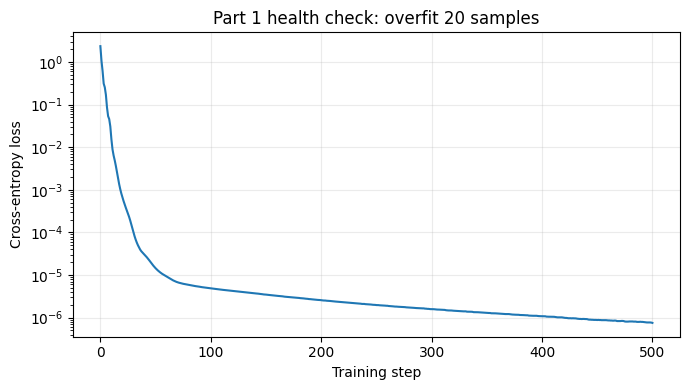

Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/figures/part1_overfit20.png
Part 1: PASS


In [23]:
import math
import random

import matplotlib.pyplot as plt
import torch.nn.functional as F

from model import (
    MLP,
    EXPECTED_PARAMS,
    activation_stats,
    count_params,
)

# Dat seed de ket qua co the lap lai
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)


# 1. Kiem tra kien truc va so tham so
model = MLP(
    hidden=(256, 128),
    dropout=0.0,
    init="he",
).to(device)

n_params = count_params(model)

assert n_params == EXPECTED_PARAMS[(256, 128)]
assert n_params == 47_879

print("M-base parameters:", n_params)


# 2. Kiem tra shape logits
model.eval()

with torch.no_grad():
    probe_logits = model(data["X_val"][:8])

assert tuple(probe_logits.shape) == (8, 7)

print("Input shape:", tuple(data["X_val"][:8].shape))
print("Logits shape:", tuple(probe_logits.shape))


# 3. Thong ke kich hoat
stats = activation_stats(
    model,
    data["X_val"][:512],
)

print(
    "Activation std after Linear layers:",
    [round(value, 4) for value in stats],
)


# 4. Loss buoc 0 tren validation
with torch.no_grad():
    step0_logits = model(data["X_val"])
    step0_loss = F.cross_entropy(
        step0_logits,
        data["y_val"],
    ).item()

expected_random_loss = math.log(7)

print(f"Step-0 CE loss: {step0_loss:.4f}")
print(f"ln(7): {expected_random_loss:.4f}")
print(
    "Absolute difference:",
    round(abs(step0_loss - expected_random_loss), 4),
)

assert math.isfinite(step0_loss)


# 5. Kiem tra gradient chay toi moi tham so
model.zero_grad(set_to_none=True)

gradient_logits = model(data["X_tr"][:512])
gradient_loss = F.cross_entropy(
    gradient_logits,
    data["y_tr"][:512],
)

gradient_loss.backward()

for name, parameter in model.named_parameters():
    grad_norm = None if parameter.grad is None else parameter.grad.norm().item()

    print(f"Gradient {name}: {grad_norm:.6f}")

    assert grad_norm is not None
    assert grad_norm > 0.0


# 6. Thu qua khop 20 mau
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

tiny_model = MLP(
    hidden=(256, 128),
    dropout=0.0,
    init="he",
).to(device)

tiny_optimizer = torch.optim.Adam(
    tiny_model.parameters(),
    lr=1e-2,
)

tiny_X = data["X_tr"][:20]
tiny_y = data["y_tr"][:20]
tiny_losses = []

tiny_model.train()

for step in range(501):
    tiny_optimizer.zero_grad(set_to_none=True)

    tiny_logits = tiny_model(tiny_X)
    tiny_loss = F.cross_entropy(
        tiny_logits,
        tiny_y,
    )

    tiny_losses.append(tiny_loss.item())

    if step == 500:
        break

    tiny_loss.backward()
    tiny_optimizer.step()


tiny_model.eval()

with torch.no_grad():
    tiny_predictions = tiny_model(tiny_X).argmax(dim=1)

    tiny_accuracy = (tiny_predictions == tiny_y).float().mean().item()

print(
    f"Overfit 20 samples: "
    f"loss={tiny_losses[-1]:.6f}, "
    f"accuracy={tiny_accuracy:.1%}"
)

assert tiny_losses[-1] < 0.02
assert tiny_accuracy == 1.0


# 7. Luu duong cong overfit
figure_path = f"{OUT_DIR}/figures/part1_overfit20.png"

plt.figure(figsize=(7, 4))
plt.plot(tiny_losses)
plt.yscale("log")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Part 1 health check: overfit 20 samples")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()

print("Saved figure:", figure_path)
print("Part 1: PASS")

**Nhận xét Part 1:** M-base có đúng 47.879 tham số và biến đổi đầu vào `(8, 54)` thành logits `(8, 7)`. Độ lệch chuẩn sau ba lớp Linear lần lượt là 0,6962; 0,6614; 0,6522 nên tín hiệu chưa bị tiêu biến hay bùng nổ.

Loss bước 0 là 2,3776, cao hơn `ln(7) = 1,9459` khoảng 0,4317. Nguyên nhân là khởi tạo He tạo logits có độ phân tán đáng kể ngay từ đầu, khiến mô hình đưa ra một số dự đoán ngẫu nhiên tương đối tự tin thay vì phân phối đều hoàn toàn. Mọi tham số đều nhận gradient khác 0.

Mô hình quá khớp thành công 20 mẫu: loss giảm còn khoảng 0,000001 và accuracy đạt 100%. Điều này cho thấy kiến trúc, nhãn, hàm mất mát, lan truyền ngược và cập nhật tham số đang hoạt động đúng.

## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

In [24]:
# ===== Smoke test: kiem tra pipeline trong 1 epoch =====
from plots import plot_run
from results_table import (
    save_result,
    to_row,
    write_xlsx,
)
from train import DEFAULT_CFG, run_experiment


smoke_cfg = {
    **DEFAULT_CFG,
    "exp_id": "smoke-1ep",
    "group": "smoke",
    "description": "Pipeline smoke test, 1 epoch",
    "lr": 0.05,
    "epochs": 1,
    "seed": 42,
}

smoke_result = run_experiment(
    smoke_cfg,
    data,
)

smoke_dir = f"{OUT_DIR}/smoke"
os.makedirs(smoke_dir, exist_ok=True)

smoke_json = save_result(
    smoke_result,
    results_dir=smoke_dir,
)

smoke_figure = f"{smoke_dir}/smoke-1ep.png"

plot_run(
    smoke_result,
    smoke_figure,
)

smoke_row = to_row(
    smoke_result,
    notes="Chi dung de kiem tra pipeline",
)

smoke_xlsx = f"{smoke_dir}/experiments_smoke.xlsx"

write_xlsx(
    [smoke_row],
    template_path=(
        f"{REPO_ROOT}/templates/"
        "experiment_table_template.xlsx"
    ),
    out_path=smoke_xlsx,
)

assert os.path.isfile(smoke_json)
assert os.path.isfile(smoke_figure)
assert os.path.isfile(smoke_xlsx)

summary = smoke_result["summary"]

print("Smoke summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")

assert not summary["diverged"]
assert summary["best_epoch"] in (0, 1)
assert np.isfinite(summary["final_train_loss"])
assert np.isfinite(summary["final_val_loss"])

print("Smoke test: PASS")

smoke-1ep step-0 loss: 2.3776
smoke-1ep epoch 01/1 | train 0.4906 | val 0.4956 | acc 0.7862 | macro-F1 0.6339 | grad 0.5534 | 1.32s
Saved result: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/smoke/smoke-1ep.json
Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/smoke/smoke-1ep.png
Saved experiment table: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/smoke/experiments_smoke.xlsx
Smoke summary:
  step0_loss: 2.3775719659278858
  best_val_loss: 0.4955862485557914
  best_epoch: 1
  final_train_loss: 0.4906272230905843
  final_val_loss: 0.4955862485557914
  val_acc: 0.786192207568684
  val_macro_f1: 0.6338679054337479
  time_per_epoch_s: 1.324165670000184
  peak_mem_MB: 190.53271484375
  diverged: False
Smoke test: PASS


tune-sgd-lr0.01 step-0 loss: 2.3776
tune-sgd-lr0.01 epoch 01/5 | train 0.5792 | val 0.5819 | acc 0.7521 | macro-F1 0.5342 | grad 0.4458 | 1.31s
tune-sgd-lr0.01 epoch 02/5 | train 0.5287 | val 0.5315 | acc 0.7748 | macro-F1 0.5889 | grad 0.5316 | 1.47s
tune-sgd-lr0.01 epoch 03/5 | train 0.4975 | val 0.5019 | acc 0.7876 | macro-F1 0.6124 | grad 0.6355 | 1.56s
tune-sgd-lr0.01 epoch 04/5 | train 0.4645 | val 0.4691 | acc 0.8029 | macro-F1 0.6422 | grad 0.7003 | 1.51s
tune-sgd-lr0.01 epoch 05/5 | train 0.4482 | val 0.4530 | acc 0.8097 | macro-F1 0.6724 | grad 0.7972 | 1.34s
Saved result: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/tuning_lr/tune-sgd-lr0.01.json
Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/tuning_lr/tune-sgd-lr0.01.png
tune-sgd-lr0.03 step-0 loss: 2.3776
tune-sgd-lr0.03 epoch 01/5 | train 0.5133 | val 0.5169 | acc 0.7791 | macro-F1 0.5861 | grad 0.5305 | 1.31s
tune-sgd-lr0.03 epoch 0

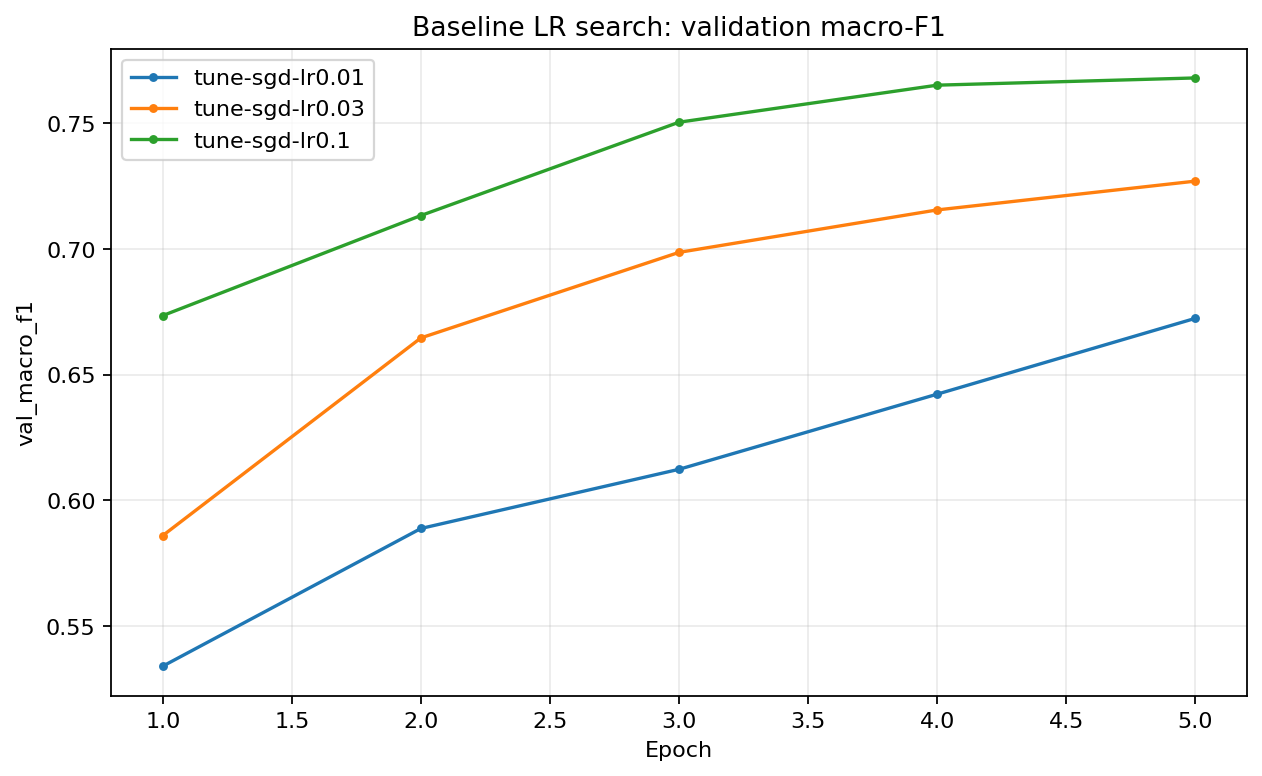

LR search: PASS


In [25]:
# ===== Tim learning rate cho baseline bang validation =====
import json

from IPython.display import Image, display
from plots import plot_compare, plot_run
from results_table import save_result
from train import DEFAULT_CFG, run_experiment

lr_candidates = [0.01, 0.03, 0.1]
lr_search_results = []
lr_search_summary = []

tuning_dir = f"{OUT_DIR}/tuning_lr"
os.makedirs(tuning_dir, exist_ok=True)

for learning_rate in lr_candidates:
    exp_id = f"tune-sgd-lr{learning_rate:g}"

    cfg = {
        **DEFAULT_CFG,
        "exp_id": exp_id,
        "group": "lr-search",
        "description": (f"SGD momentum learning-rate search, " f"lr={learning_rate}"),
        "lr": learning_rate,
        "epochs": 5,
        "seed": 42,
    }

    result = run_experiment(cfg, data)
    lr_search_results.append(result)

    save_result(
        result,
        results_dir=tuning_dir,
    )

    plot_run(
        result,
        f"{tuning_dir}/{exp_id}.png",
    )

    best_macro_f1 = max(result["history"]["val_macro_f1"])

    best_macro_epoch = result["history"]["val_macro_f1"].index(best_macro_f1) + 1

    lr_search_summary.append(
        {
            "lr": learning_rate,
            "best_val_macro_f1": best_macro_f1,
            "best_macro_epoch": best_macro_epoch,
            "best_val_loss": result["summary"]["best_val_loss"],
            "diverged": result["summary"]["diverged"],
        }
    )


valid_candidates = [item for item in lr_search_summary if not item["diverged"]]

best_candidate = max(
    valid_candidates,
    key=lambda item: item["best_val_macro_f1"],
)

best_lr = best_candidate["lr"]

print("\nLearning-rate search:")
print("lr       best val macro-F1    epoch    best val loss")

for item in lr_search_summary:
    print(
        f"{item['lr']:<8g} "
        f"{item['best_val_macro_f1']:<20.4f} "
        f"{item['best_macro_epoch']:<8d} "
        f"{item['best_val_loss']:.4f}"
    )

print(f"\nSelected baseline learning rate: {best_lr}")

summary_path = f"{tuning_dir}/lr_search_summary.json"

with open(
    summary_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        lr_search_summary,
        file,
        indent=2,
    )

comparison_path = f"{tuning_dir}/compare_lr_macro_f1.png"

plot_compare(
    lr_search_results,
    metric="val_macro_f1",
    path=comparison_path,
    title=("Baseline LR search: " "validation macro-F1"),
)

display(Image(filename=comparison_path))

print("LR search: PASS")

**Dự đoán baseline:** Với SGD momentum, `lr=0.1` được chọn bằng validation và 20 epoch, train/validation loss dự kiến giảm ổn định; accuracy phải vượt rõ mốc lớp đa số 0,4876. Kết quả giữa các seed sẽ dao động nhẹ, vì vậy cần dùng trung bình ± độ lệch chuẩn trước khi kết luận cấu hình khác tốt hơn baseline.

base-s1 step-0 loss: 2.2691
base-s1 epoch 01/20 | train 0.4628 | val 0.4675 | acc 0.7997 | macro-F1 0.6243 | grad 0.5296 | 1.31s
base-s1 epoch 02/20 | train 0.3943 | val 0.3996 | acc 0.8300 | macro-F1 0.7038 | grad 0.5667 | 1.29s
base-s1 epoch 03/20 | train 0.3784 | val 0.3862 | acc 0.8357 | macro-F1 0.7256 | grad 0.5643 | 1.29s
base-s1 epoch 04/20 | train 0.3706 | val 0.3800 | acc 0.8455 | macro-F1 0.7412 | grad 0.5749 | 1.30s
base-s1 epoch 05/20 | train 0.3097 | val 0.3204 | acc 0.8671 | macro-F1 0.7825 | grad 0.5716 | 1.38s
base-s1 epoch 06/20 | train 0.3045 | val 0.3151 | acc 0.8707 | macro-F1 0.7949 | grad 0.5866 | 1.49s
base-s1 epoch 07/20 | train 0.2936 | val 0.3047 | acc 0.8745 | macro-F1 0.7924 | grad 0.5802 | 1.55s
base-s1 epoch 08/20 | train 0.2798 | val 0.2936 | acc 0.8780 | macro-F1 0.7961 | grad 0.5714 | 1.34s
base-s1 epoch 09/20 | train 0.2912 | val 0.3068 | acc 0.8772 | macro-F1 0.8026 | grad 0.5750 | 1.33s
base-s1 epoch 10/20 | train 0.2733 | val 0.2900 | acc 0.8833 | 

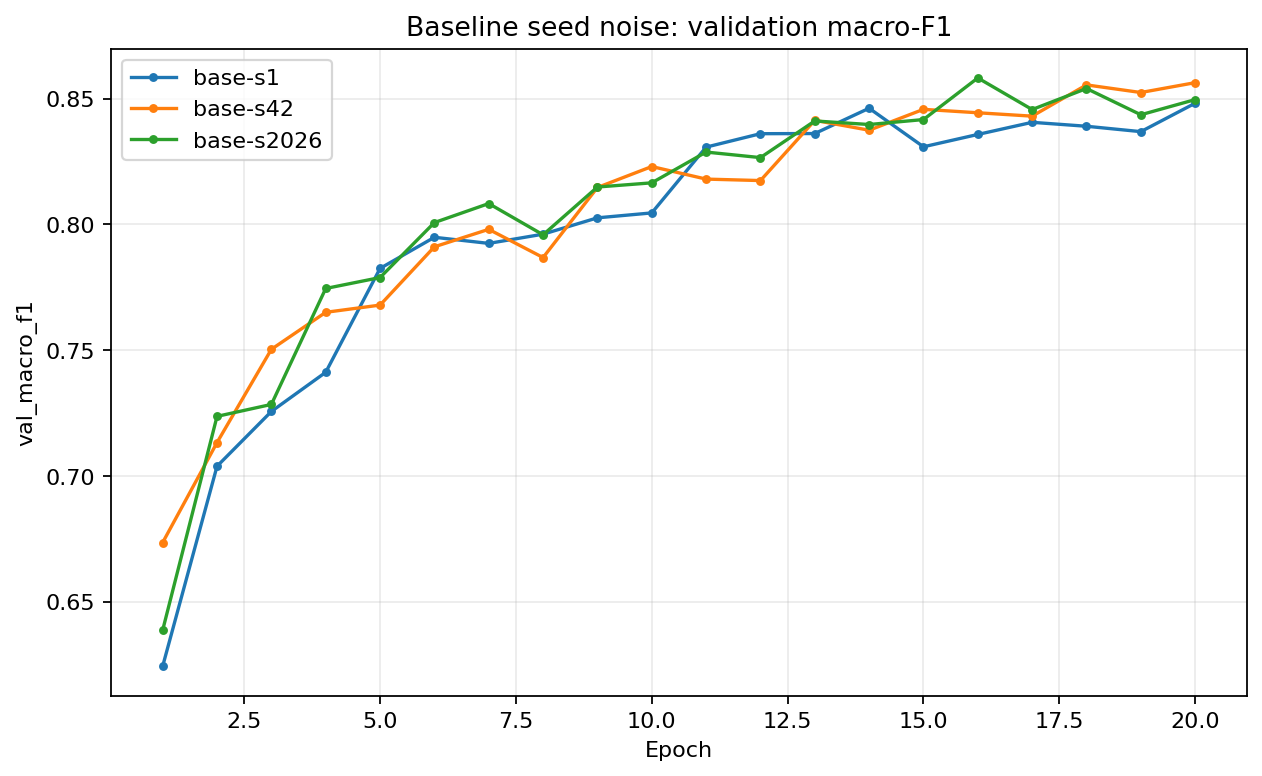

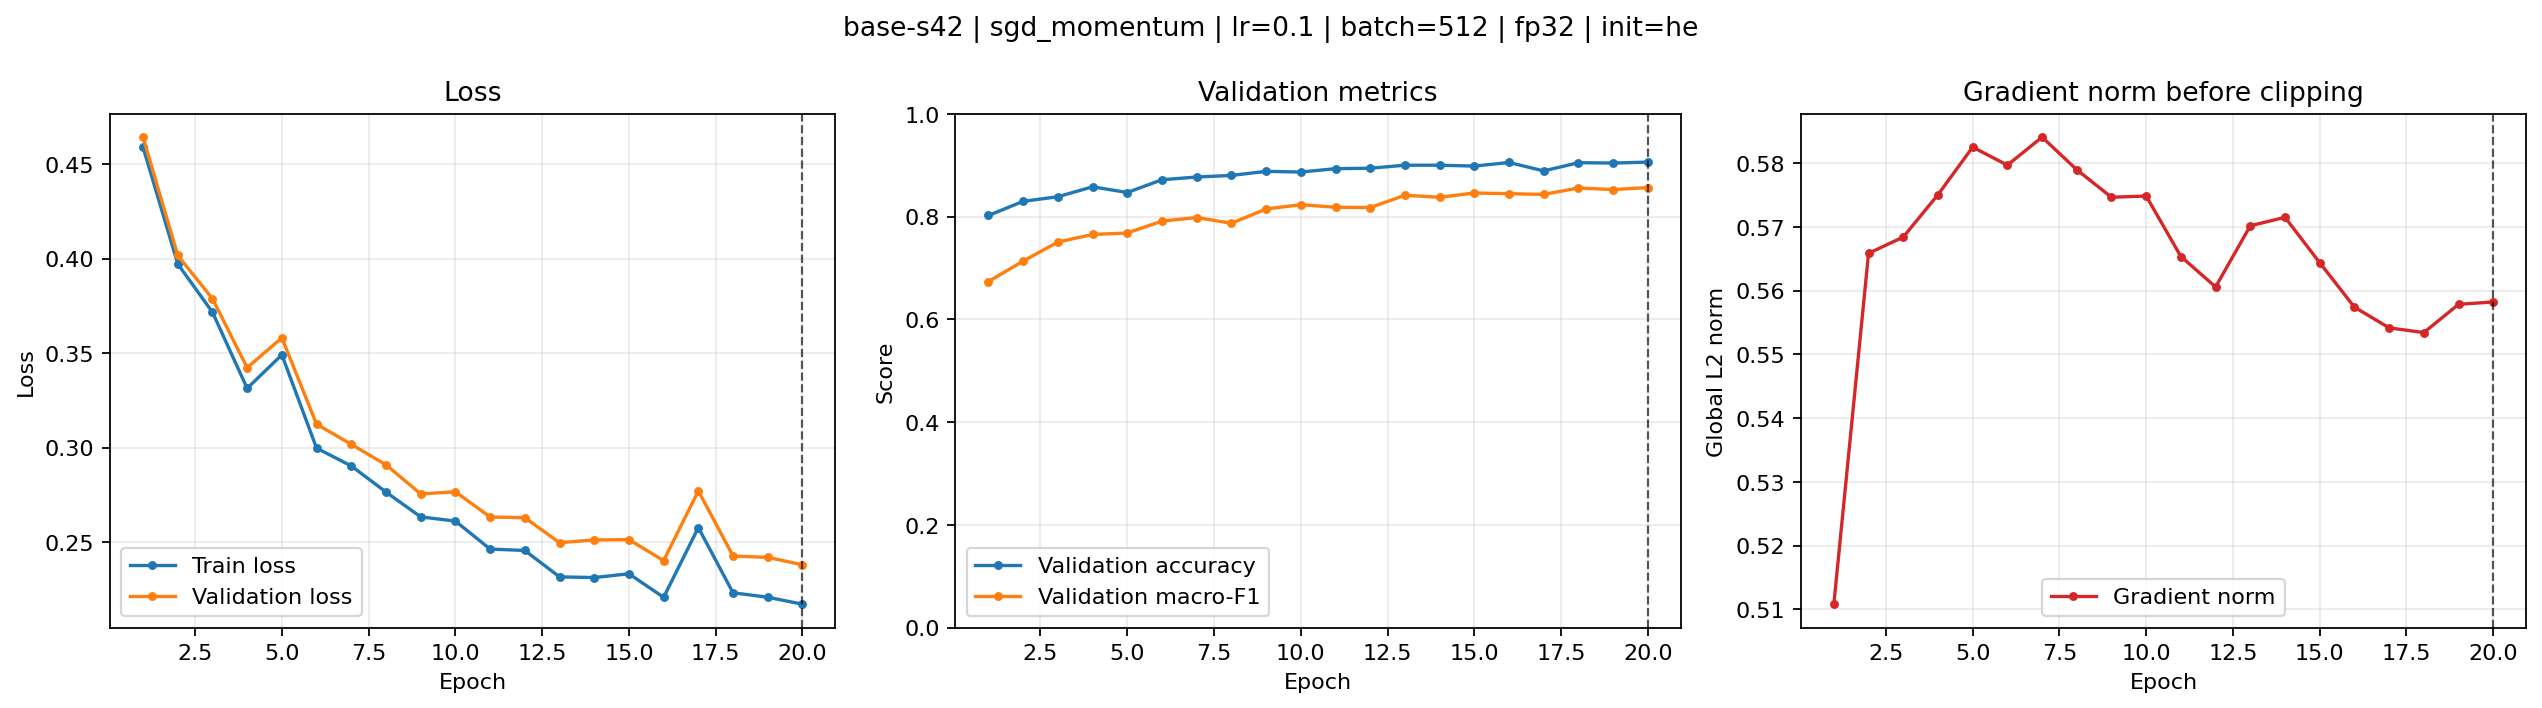

Baseline 3 seeds: PASS


In [26]:
# ===== Baseline 20 epoch, 3 seed =====
from IPython.display import Image, display

from plots import plot_compare, plot_run
from results_table import save_result, to_row, write_xlsx
from train import DEFAULT_CFG, run_experiment

baseline_lr = 0.1
baseline_seeds = [1, 42, 2026]
baseline_results = []

for seed in baseline_seeds:
    exp_id = f"base-s{seed}"

    cfg = {
        **DEFAULT_CFG,
        "exp_id": exp_id,
        "group": "baseline",
        "description": (
            "M-base, CE, SGD momentum 0.9, " f"lr={baseline_lr}, seed={seed}"
        ),
        "lr": baseline_lr,
        "epochs": 20,
        "seed": seed,
    }

    result = run_experiment(cfg, data)
    baseline_results.append(result)

    save_result(
        result,
        results_dir=f"{OUT_DIR}/results",
    )

    plot_run(
        result,
        path=f"{OUT_DIR}/figures/{exp_id}.png",
    )


baseline_by_seed = {result["cfg"]["seed"]: result for result in baseline_results}

# Seed 42 la baseline tham chieu cho cac thi nghiem sau
baseline_result = baseline_by_seed[42]

baseline_acc = np.array([result["summary"]["val_acc"] for result in baseline_results])

baseline_f1 = np.array(
    [result["summary"]["val_macro_f1"] for result in baseline_results]
)

baseline_loss = np.array(
    [result["summary"]["best_val_loss"] for result in baseline_results]
)

noise_summary = {
    "seeds": baseline_seeds,
    "val_acc_mean": float(baseline_acc.mean()),
    "val_acc_std": float(baseline_acc.std(ddof=1)),
    "val_macro_f1_mean": float(baseline_f1.mean()),
    "val_macro_f1_std": float(baseline_f1.std(ddof=1)),
    "best_val_loss_mean": float(baseline_loss.mean()),
    "best_val_loss_std": float(baseline_loss.std(ddof=1)),
}

print("\nBaseline seed results:")
print("seed   best epoch   val acc   val macro-F1   val loss")

for result in baseline_results:
    summary = result["summary"]

    print(
        f"{result['cfg']['seed']:<6d} "
        f"{summary['best_epoch']:<12d} "
        f"{summary['val_acc']:<9.4f} "
        f"{summary['val_macro_f1']:<14.4f} "
        f"{summary['best_val_loss']:.4f}"
    )

print(
    "\nValidation accuracy: "
    f"{noise_summary['val_acc_mean']:.4f} "
    f"± {noise_summary['val_acc_std']:.4f}"
)

print(
    "Validation macro-F1: "
    f"{noise_summary['val_macro_f1_mean']:.4f} "
    f"± {noise_summary['val_macro_f1_std']:.4f}"
)

with open(
    f"{OUT_DIR}/results/baseline_noise.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        noise_summary,
        file,
        indent=2,
    )


compare_f1_path = f"{OUT_DIR}/figures/" "compare_baseline_seeds_f1.png"

plot_compare(
    baseline_results,
    metric="val_macro_f1",
    path=compare_f1_path,
    title="Baseline seed noise: validation macro-F1",
)

compare_loss_path = f"{OUT_DIR}/figures/" "compare_baseline_seeds_loss.png"

plot_compare(
    baseline_results,
    metric="val_loss",
    path=compare_loss_path,
    title="Baseline seed noise: validation loss",
)


baseline_rows = [
    to_row(
        result,
        notes=("Baseline seed repeat; " "lr selected using validation"),
    )
    for result in baseline_results
]

write_xlsx(
    baseline_rows,
    template_path=(f"{REPO_ROOT}/templates/" "experiment_table_template.xlsx"),
    out_path=f"{OUT_DIR}/experiments.xlsx",
)

display(Image(filename=compare_f1_path))
display(Image(filename=(f"{OUT_DIR}/figures/base-s42.png")))

print("Baseline 3 seeds: PASS")

**Nhận xét baseline:** Learning rate `0,1` được chọn bằng validation sau khi thử `0,01`, `0,03` và `0,1`. Với 20 epoch, cả ba seed đều vượt xa mốc đoán lớp đa số 0,4876.

Kết quả tốt nhất theo validation loss:

- Seed 1: best epoch 18, val accuracy 0,9054, val macro-F1 0,8390, val loss 0,2379.
- Seed 42: best epoch 20, val accuracy 0,9059, val macro-F1 0,8564, val loss 0,2380.
- Seed 2026: best epoch 20, val accuracy 0,9086, val macro-F1 0,8496, val loss 0,2302.

Trung bình validation accuracy là `0,9066 ± 0,0017`; validation macro-F1 là `0,8484 ± 0,0087`. Vì vậy, chênh lệch macro-F1 nhỏ hơn khoảng `2σ = 0,0174` chưa đủ mạnh để khẳng định một cấu hình tốt hơn baseline.

Train loss và validation loss nhìn chung cùng giảm; khoảng cách ở seed 42 tại epoch 20 nhỏ (`0,2380 - 0,2172 ≈ 0,0208`), chưa có dấu hiệu quá khớp rõ. Macro-F1 vẫn tăng về cuối quá trình huấn luyện. Gradient norm ổn định khoảng 0,51–0,58, không có hiện tượng bùng nổ gradient.

## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm 1 — Bộ tối ưu

**Dự đoán trước:** Adam có thể hội tụ nhanh hơn SGD Momentum trong các epoch đầu nhờ learning rate thích nghi theo từng tham số. Tuy nhiên, kết quả cuối có thể chỉ chênh nhẹ và nằm trong nhiễu giữa các seed. Tôi giữ nguyên kiến trúc, loss, batch size, seed, số epoch và cách khởi tạo; mỗi optimizer được đánh giá với ít nhất hai learning rate.


Loaded existing result: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/results/opt-sgdm-lr0.03.json
Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/figures/opt-sgdm-lr0.03.png
Loaded existing result: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/results/opt-adam-lr3e-4.json
Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/figures/opt-adam-lr3e-4.png
Loaded existing result: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/results/opt-adam-lr1e-3.json
Saved figure: /content/drive/MyDrive/AICB2026/K4-Track4-Day1-Neuralnetwork/submission_2A202602364/figures/opt-adam-lr1e-3.png

Optimizer results:
exp_id               optimizer       lr       epoch   val_acc   macro-F1   delta
base-s42             sgd_momentum    0.1      20      0.9059    0.8564     +0.0000
opt-sgdm-lr0.03      sgd_mo

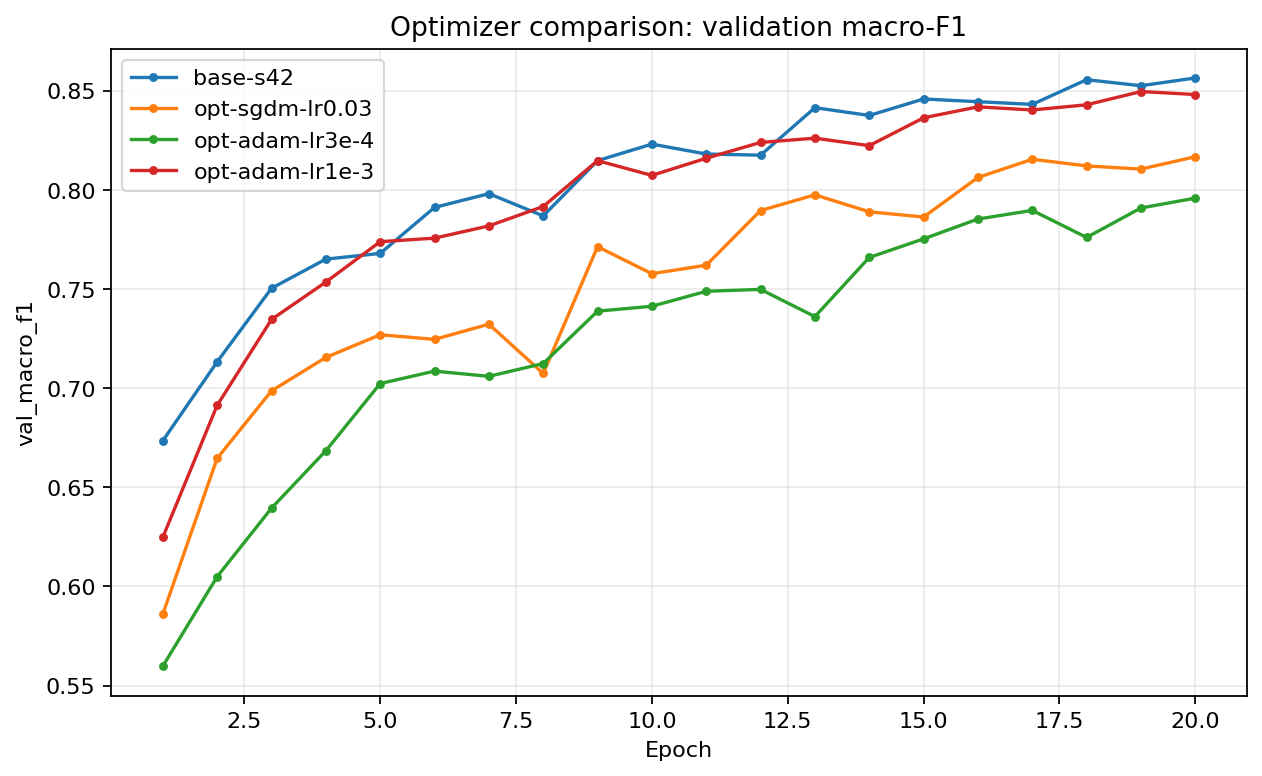

Optimizer experiment: PASS


In [27]:
# ===== Part 3.1: optimizer =====
import importlib
import json
import os

from IPython.display import Image, display
from plots import plot_compare, plot_run
import results_table as results_table_module
from train import DEFAULT_CFG, run_experiment

# Dam bao runtime dang dung phien ban moi nhat cua results_table.py.
results_table_module = importlib.reload(results_table_module)
load_results = results_table_module.load_results
save_result = results_table_module.save_result
to_row = results_table_module.to_row
write_xlsx = results_table_module.write_xlsx


def load_experiment(path):
    with open(path, "r", encoding="utf-8") as file:
        result = json.load(file)

    required_keys = {"cfg", "history", "summary"}

    if not required_keys.issubset(result):
        raise ValueError(f"File khong phai ket qua thi nghiem: {path}")

    return result


# Baseline seed 42, SGD Momentum lr=0.1 la ung vien thu nhat cua SGD Momentum.
baseline_path = f"{OUT_DIR}/results/base-s42.json"

if not os.path.isfile(baseline_path):
    raise FileNotFoundError("Can chay baseline base-s42 o Part 2 truoc Part 3")

baseline_reference = load_experiment(baseline_path)

optimizer_specs = [
    ("opt-sgdm-lr0.03", "sgd_momentum", 0.03),
    ("opt-adam-lr3e-4", "adam", 3e-4),
    ("opt-adam-lr1e-3", "adam", 1e-3),
]

optimizer_results = []

for exp_id, optimizer_name, learning_rate in optimizer_specs:
    result_path = f"{OUT_DIR}/results/{exp_id}.json"

    if os.path.isfile(result_path):
        result = load_experiment(result_path)
        print("Loaded existing result:", result_path)
    else:
        cfg = {
            **DEFAULT_CFG,
            "exp_id": exp_id,
            "group": "optimizer",
            "description": (
                f"M-base, CE, {optimizer_name}, "
                f"lr={learning_rate}, seed=42"
            ),
            "optimizer": optimizer_name,
            "lr": learning_rate,
            "epochs": 20,
            "seed": 42,
        }

        result = run_experiment(cfg, data)
        save_result(result, results_dir=f"{OUT_DIR}/results")

    optimizer_results.append(result)
    plot_run(result, path=f"{OUT_DIR}/figures/{exp_id}.png")

comparison_results = [baseline_reference, *optimizer_results]
baseline_f1 = baseline_reference["summary"]["val_macro_f1"]

print("\nOptimizer results:")
print("exp_id               optimizer       lr       epoch   val_acc   macro-F1   delta")

for result in comparison_results:
    cfg = result["cfg"]
    summary = result["summary"]
    print(
        f"{cfg['exp_id']:<20} "
        f"{cfg['optimizer']:<15} "
        f"{cfg['lr']:<8g} "
        f"{summary['best_epoch']:<7d} "
        f"{summary['val_acc']:<9.4f} "
        f"{summary['val_macro_f1']:<10.4f} "
        f"{summary['val_macro_f1'] - baseline_f1:+.4f}"
    )

sgdm_results = [
    result
    for result in comparison_results
    if result["cfg"]["optimizer"] == "sgd_momentum"
]
adam_results = [
    result
    for result in comparison_results
    if result["cfg"]["optimizer"] == "adam"
]

best_sgdm = max(sgdm_results, key=lambda result: result["summary"]["val_macro_f1"])
best_adam = max(adam_results, key=lambda result: result["summary"]["val_macro_f1"])

with open(
    f"{OUT_DIR}/results/baseline_noise.json",
    "r",
    encoding="utf-8",
) as file:
    noise_summary = json.load(file)

noise_threshold = 2 * noise_summary["val_macro_f1_std"]
optimizer_delta = (
    best_adam["summary"]["val_macro_f1"]
    - best_sgdm["summary"]["val_macro_f1"]
)

print("\nSelected by validation macro-F1:")
print(
    f"Best SGD Momentum: {best_sgdm['cfg']['exp_id']} | "
    f"F1={best_sgdm['summary']['val_macro_f1']:.4f}"
)
print(
    f"Best Adam:         {best_adam['cfg']['exp_id']} | "
    f"F1={best_adam['summary']['val_macro_f1']:.4f}"
)
print(f"Adam - SGD Momentum: {optimizer_delta:+.4f}")
print(f"Baseline 2-sigma threshold: {noise_threshold:.4f}")

compare_path = f"{OUT_DIR}/figures/compare_optimizer_f1.png"
plot_compare(
    comparison_results,
    metric="val_macro_f1",
    path=compare_path,
    title="Optimizer comparison: validation macro-F1",
)

all_results = load_results(f"{OUT_DIR}/results")
rows = []

for result in all_results:
    group = result["cfg"].get("group")
    notes = (
        "Optimizer comparison; seed=42; other settings follow baseline"
        if group == "optimizer"
        else "Baseline seed repeat; lr selected using validation"
    )
    rows.append(to_row(result, notes=notes))

write_xlsx(
    rows,
    template_path=(
        f"{REPO_ROOT}/templates/experiment_table_template.xlsx"
    ),
    out_path=f"{OUT_DIR}/experiments.xlsx",
)

display(Image(filename=compare_path))
print("Optimizer experiment: PASS")


**Đối chiếu sau khi chạy:** Dự đoán Adam hội tụ nhanh hơn không được xác nhận rõ ở các learning rate đã thử. Trong 20 epoch, SGD Momentum với `lr=0,1` đạt kết quả tốt nhất: validation accuracy `0,9059`, macro-F1 `0,8564` và validation loss `0,2380`. Learning rate `0,03` của cùng optimizer hội tụ chậm hơn, chỉ đạt macro-F1 `0,8166`.

Với Adam, `lr=0,001` tốt hơn rõ rệt so với `0,0003`: cấu hình tốt nhất được chọn tại epoch 19, đạt validation accuracy `0,9032`, macro-F1 `0,8495` và validation loss `0,2414`. Adam `lr=0,0003` chỉ đạt macro-F1 `0,7958`, cho thấy learning rate này quá nhỏ cho ngân sách 20 epoch.

Best Adam thấp hơn best SGD Momentum `0,0069` macro-F1. Chênh lệch này nhỏ hơn ngưỡng nhiễu baseline `2σ = 0,0175`, nên chưa đủ bằng chứng để kết luận hai optimizer khác nhau đáng kể về khả năng tổng quát hóa. Các lần chạy không phân kỳ; gradient norm vẫn hữu hạn. Vì SGD Momentum `lr=0,1` có điểm validation cao nhất và là cấu hình đơn giản hơn, tôi tiếp tục giữ `base-s42` làm cấu hình tham chiếu hiện tại.


### Thí nghiệm 2–7 — Các chủ đề còn lại

**Hàm mất mát:** Cross-entropy được dự đoán cho macro-F1 cao hơn MSE vì gradient của nó phù hợp trực tiếp với bài toán phân loại. Hai loss khác thang đo nên tôi chỉ so accuracy, macro-F1 và tốc độ hội tụ, không so độ lớn loss.

**Hyper-parameter (kiến trúc):** M-wide và M-deep có năng lực biểu diễn lớn hơn M-base. Vì baseline chưa có khoảng cách train–validation lớn, tôi dự đoán tăng năng lực có thể cải thiện validation macro-F1; tuy nhiên mạng lớn hơn cũng tốn thời gian và bộ nhớ hơn.

**Dropout:** Baseline chỉ có khoảng cách train–validation loss nhỏ, nên dropout `0,2` có thể không cải thiện rõ; dropout `0,5` được dự đoán gây thiếu khớp trong ngân sách 20 epoch.

**Gradient clipping:** Gradient norm baseline chủ yếu khoảng `0,51–0,58`, chưa có dấu hiệu bùng nổ. Tôi chọn ngưỡng `c=0,6`, xấp xỉ cận trên quan sát được, rồi so có/không clipping ở learning rate cao `0,3`. Clipping chỉ được kỳ vọng giúp nếu stress test tạo gradient vượt ngưỡng hoặc dao động mạnh.

**Mixed precision:** FP16 được dự đoán giảm bộ nhớ và có thể giảm thời gian mỗi epoch trên Tesla T4; macro-F1 nên gần FP32 nếu GradScaler hoạt động đúng.

**Khởi tạo:** Xavier được dự đoán vẫn học được nhưng có thể kém He với ReLU. Khởi tạo toàn số 0 được dự đoán thất bại do các nơ-ron trong cùng lớp nhận gradient giống nhau và không phá được đối xứng.


loss-mse step-0 loss: 0.6062
loss-mse epoch 01/20 | train 0.0498 | val 0.0501 | acc 0.7577 | macro-F1 0.4417 | grad 0.0595 | 1.51s
loss-mse epoch 02/20 | train 0.0447 | val 0.0450 | acc 0.7857 | macro-F1 0.5385 | grad 0.0563 | 1.61s
loss-mse epoch 03/20 | train 0.0420 | val 0.0425 | acc 0.7965 | macro-F1 0.5664 | grad 0.0639 | 1.60s
loss-mse epoch 04/20 | train 0.0397 | val 0.0402 | acc 0.8099 | macro-F1 0.6098 | grad 0.0695 | 1.38s
loss-mse epoch 05/20 | train 0.0381 | val 0.0386 | acc 0.8194 | macro-F1 0.6319 | grad 0.0744 | 1.35s
loss-mse epoch 06/20 | train 0.0369 | val 0.0374 | acc 0.8242 | macro-F1 0.6361 | grad 0.0779 | 1.34s
loss-mse epoch 07/20 | train 0.0361 | val 0.0367 | acc 0.8283 | macro-F1 0.6471 | grad 0.0825 | 1.35s
loss-mse epoch 08/20 | train 0.0358 | val 0.0364 | acc 0.8324 | macro-F1 0.6503 | grad 0.0840 | 1.33s
loss-mse epoch 09/20 | train 0.0340 | val 0.0347 | acc 0.8393 | macro-F1 0.6742 | grad 0.0869 | 1.34s
loss-mse epoch 10/20 | train 0.0346 | val 0.0352 | ac

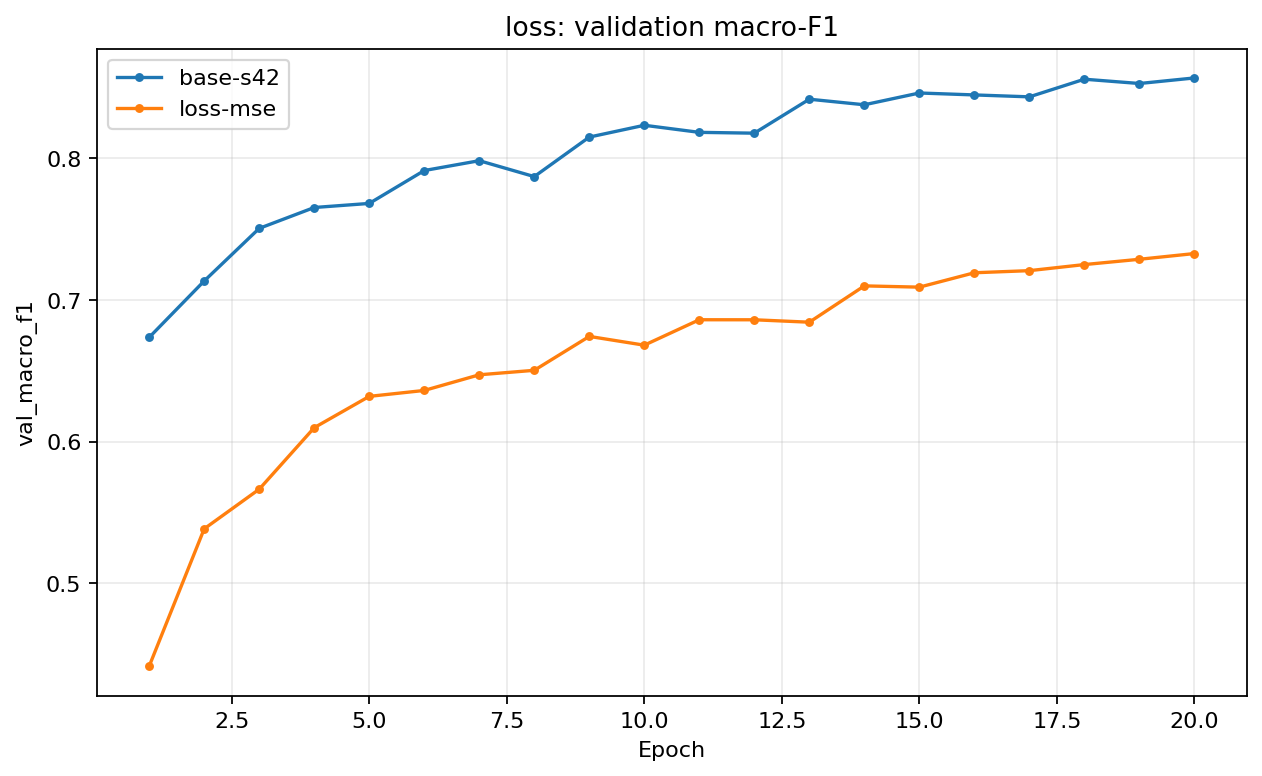

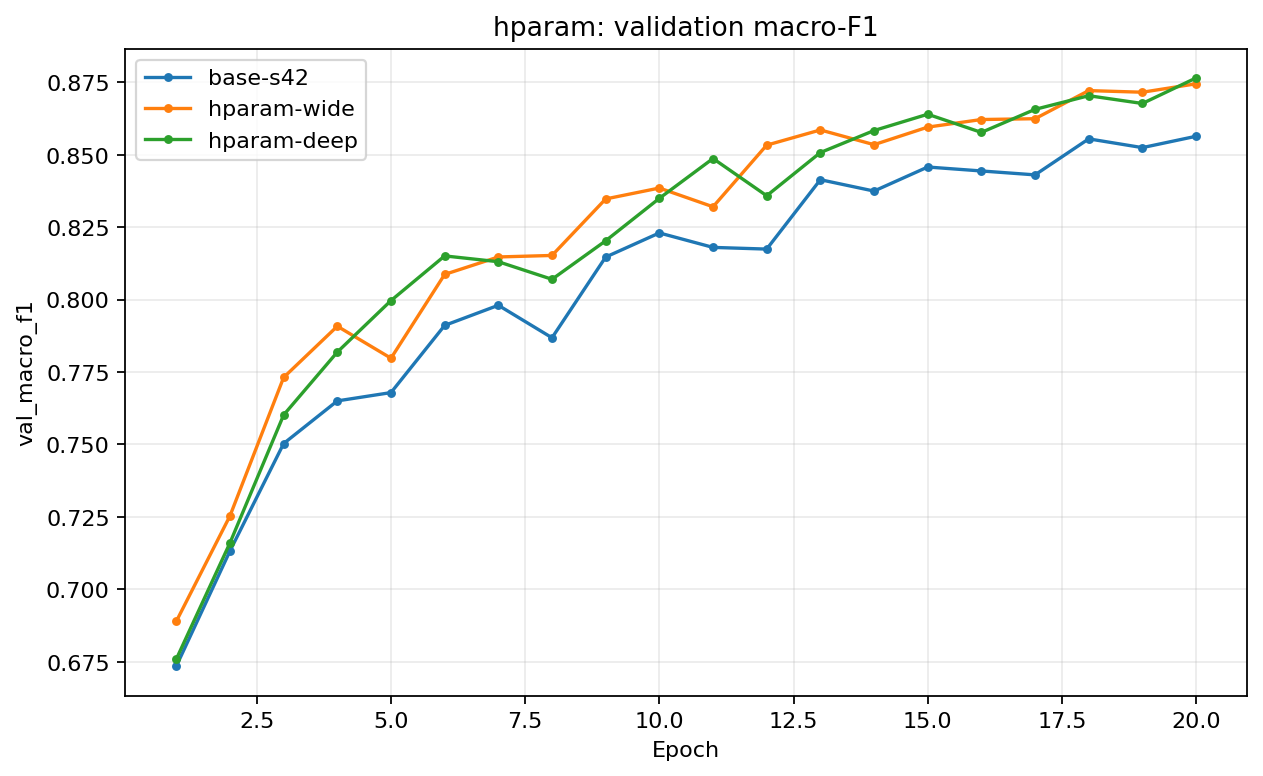

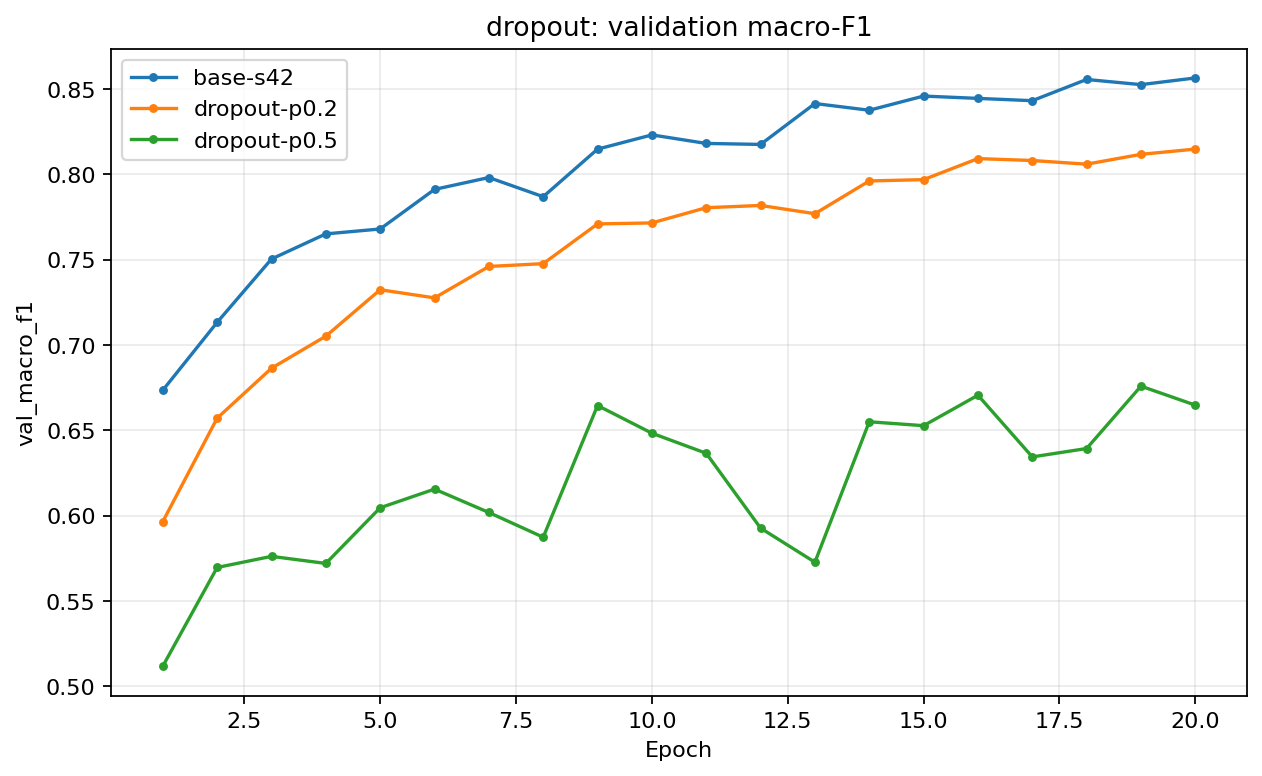

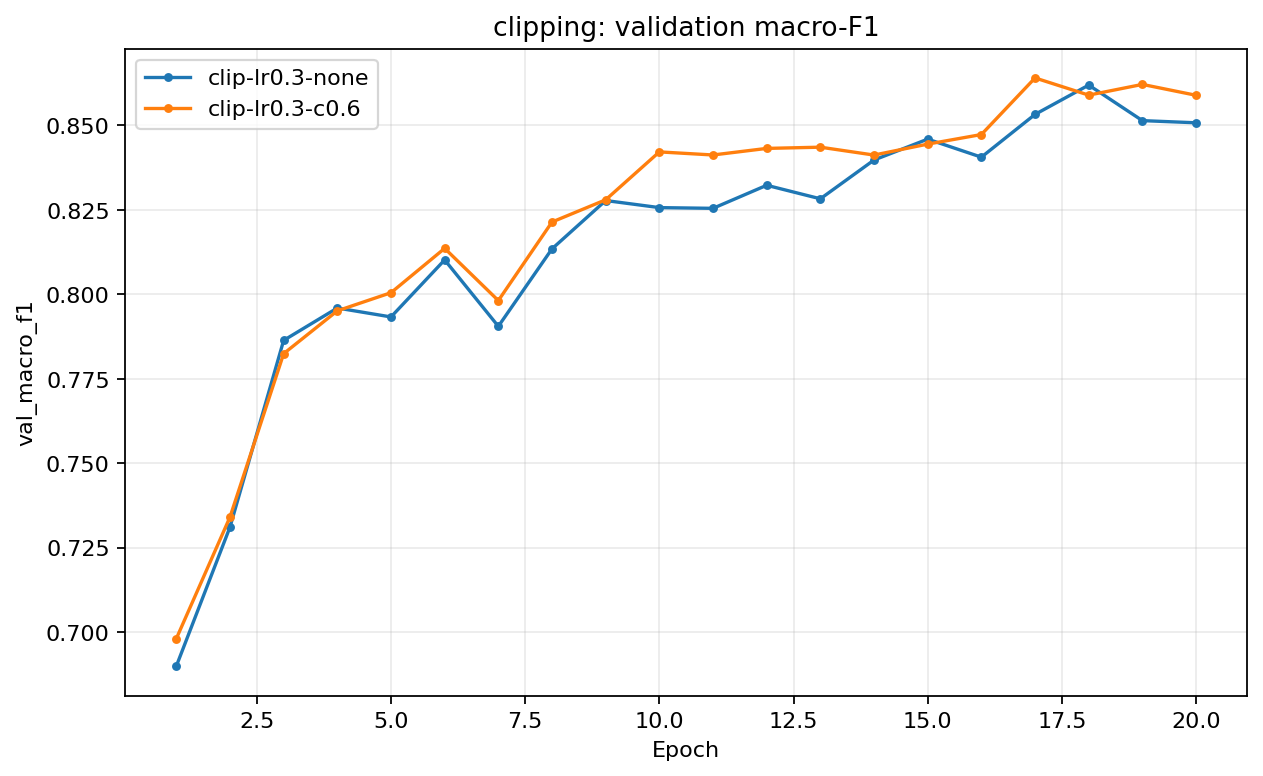

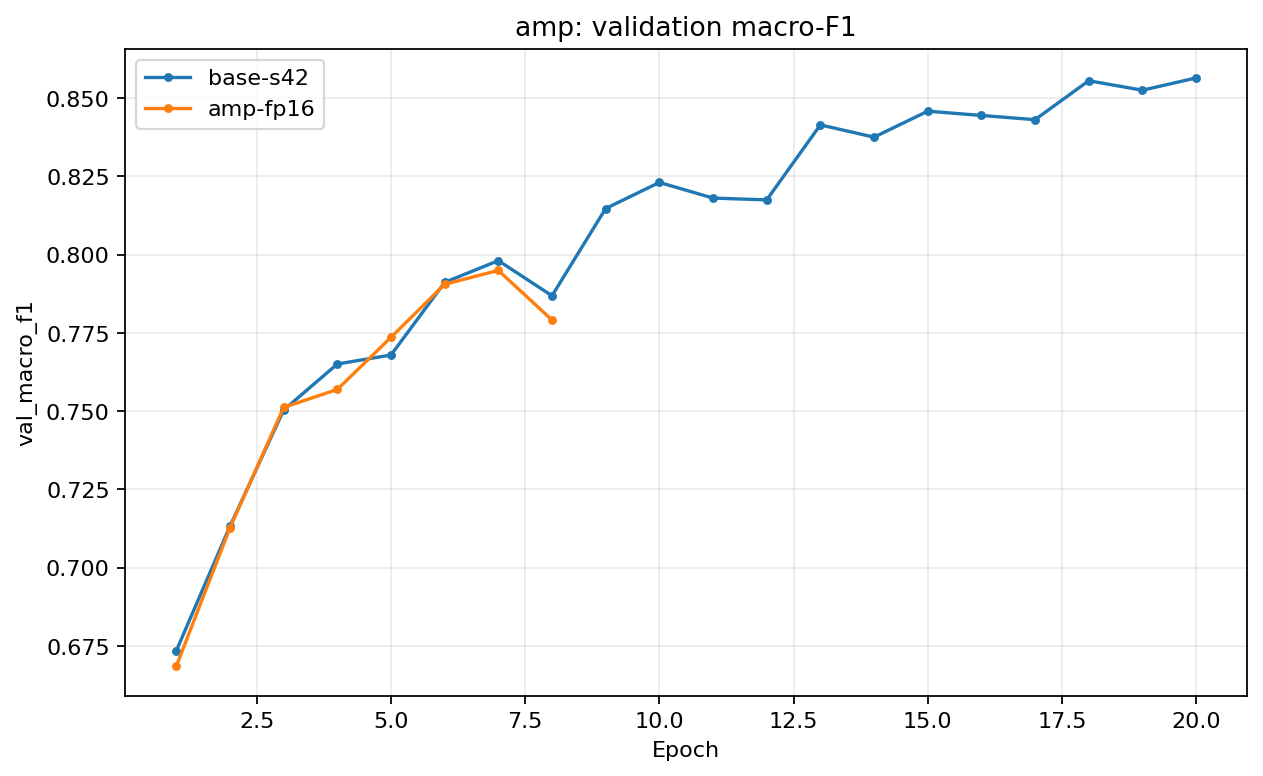

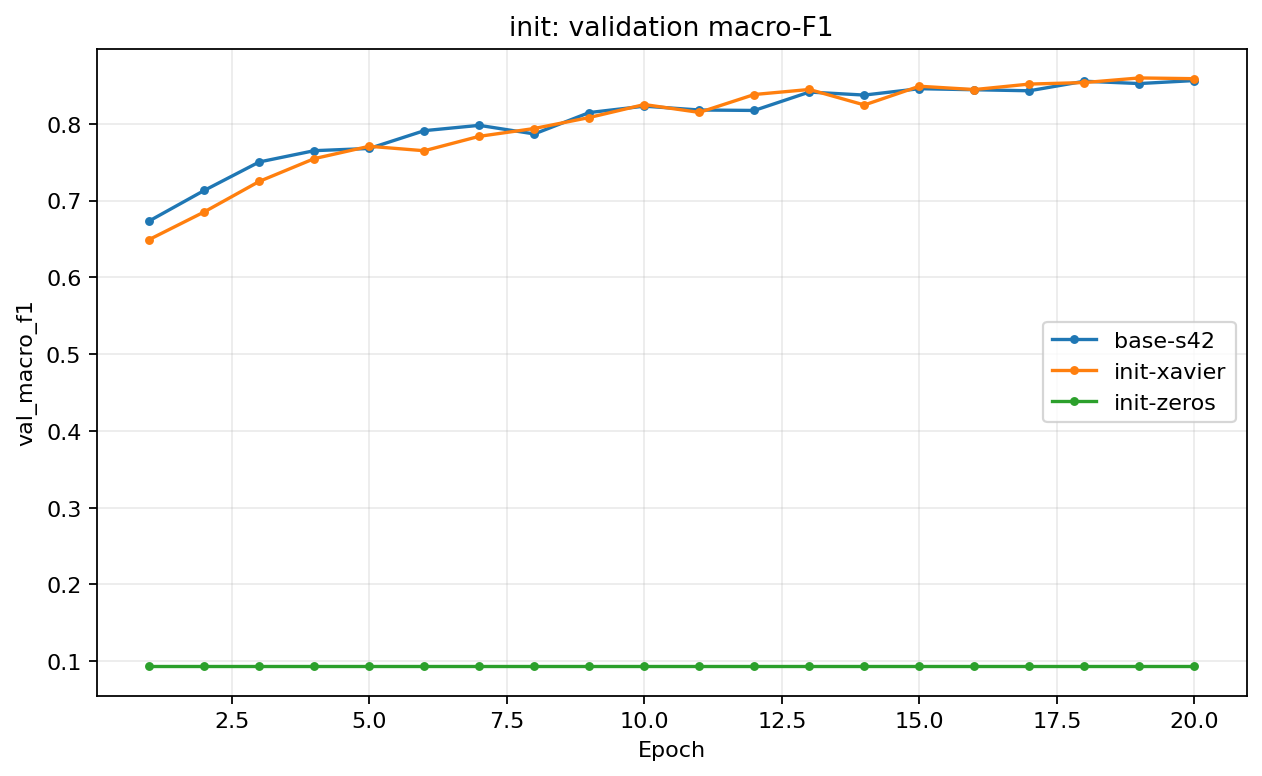

Part 3 all topics: PASS


In [28]:
# ===== Part 3.2-3.7: remaining experiment topics =====
import importlib
import json
import math
import os

from IPython.display import Image, display
from model import MLP, activation_stats, count_params
from plots import plot_compare, plot_run
import results_table as results_table_module
from train import DEFAULT_CFG, run_experiment, set_seed

results_table_module = importlib.reload(results_table_module)
load_results = results_table_module.load_results
save_result = results_table_module.save_result
to_row = results_table_module.to_row
write_xlsx = results_table_module.write_xlsx


def load_experiment(path):
    with open(path, "r", encoding="utf-8") as file:
        result = json.load(file)

    if not {"cfg", "history", "summary"}.issubset(result):
        raise ValueError(f"File khong phai ket qua thi nghiem: {path}")

    return result


def run_or_load(spec):
    exp_id = spec["exp_id"]
    result_path = f"{OUT_DIR}/results/{exp_id}.json"

    if os.path.isfile(result_path):
        result = load_experiment(result_path)
        print("Loaded existing result:", result_path)
    else:
        cfg = {
            **DEFAULT_CFG,
            "exp_id": exp_id,
            "group": spec["group"],
            "description": spec["description"],
            "lr": 0.1,
            "epochs": 20,
            "seed": 42,
            **spec.get("changes", {}),
        }
        result = run_experiment(cfg, data)
        save_result(result, results_dir=f"{OUT_DIR}/results")

    plot_run(result, path=f"{OUT_DIR}/figures/{exp_id}.png")

    return result


baseline_reference = load_experiment(
    f"{OUT_DIR}/results/base-s42.json"
)

experiment_specs = [
    {
        "exp_id": "loss-mse",
        "group": "loss",
        "description": "MSE one-hot vs baseline cross-entropy",
        "changes": {"loss": "mse"},
    },
    {
        "exp_id": "hparam-wide",
        "group": "hparam",
        "description": "M-wide 54-512-256-7",
        "changes": {"hidden": (512, 256)},
    },
    {
        "exp_id": "hparam-deep",
        "group": "hparam",
        "description": "M-deep 54-256-128-64-7",
        "changes": {"hidden": (256, 128, 64)},
    },
    {
        "exp_id": "dropout-p0.2",
        "group": "dropout",
        "description": "Dropout probability 0.2",
        "changes": {"dropout": 0.2},
    },
    {
        "exp_id": "dropout-p0.5",
        "group": "dropout",
        "description": "Dropout probability 0.5",
        "changes": {"dropout": 0.5},
    },
    {
        "exp_id": "clip-lr0.3-none",
        "group": "clipping",
        "description": "High-lr stress test without clipping",
        "changes": {"lr": 0.3, "clip_norm": None},
    },
    {
        "exp_id": "clip-lr0.3-c0.6",
        "group": "clipping",
        "description": "High-lr stress test with clip norm 0.6",
        "changes": {"lr": 0.3, "clip_norm": 0.6},
    },
    {
        "exp_id": "amp-fp16",
        "group": "amp",
        "description": "FP16 autocast with GradScaler",
        "changes": {"precision": "fp16"},
    },
    {
        "exp_id": "init-xavier",
        "group": "init",
        "description": "Xavier initialization",
        "changes": {"init": "xavier"},
    },
    {
        "exp_id": "init-zeros",
        "group": "init",
        "description": "All-zero weight initialization",
        "changes": {"init": "zeros"},
    },
]

remaining_results = [run_or_load(spec) for spec in experiment_specs]
results_by_group = {}

for result in remaining_results:
    results_by_group.setdefault(result["cfg"]["group"], []).append(result)

for group, group_results in results_by_group.items():
    comparison = group_results

    if group != "clipping":
        comparison = [baseline_reference, *group_results]

    compare_path = f"{OUT_DIR}/figures/compare_{group}_f1.png"
    plot_compare(
        comparison,
        metric="val_macro_f1",
        path=compare_path,
        title=f"{group}: validation macro-F1",
    )

print("\nPart 3 experiment summary:")
print("group       exp_id                  val_acc   macro-F1   val_loss   time/epoch")

for result in remaining_results:
    cfg = result["cfg"]
    summary = result["summary"]
    print(
        f"{cfg['group']:<11} "
        f"{cfg['exp_id']:<23} "
        f"{summary['val_acc']:<9.4f} "
        f"{summary['val_macro_f1']:<10.4f} "
        f"{summary['best_val_loss']:<10.4f} "
        f"{summary['time_per_epoch_s']:.3f}s"
    )

print("\nClipping diagnostics (gradient norm is measured before clipping):")

for result in results_by_group["clipping"]:
    gradients = result["history"]["grad_norm"]
    print(
        f"{result['cfg']['exp_id']}: "
        f"mean={sum(gradients) / len(gradients):.4f}, "
        f"max={max(gradients):.4f}, "
        f"diverged={result['summary']['diverged']}"
    )

print("\nDropout diagnostics:")

for result in [baseline_reference, *results_by_group["dropout"]]:
    summary = result["summary"]
    gap = summary["final_val_loss"] - summary["final_train_loss"]
    print(
        f"{result['cfg']['exp_id']}: "
        f"val-train loss gap={gap:.4f}, "
        f"macro-F1={summary['val_macro_f1']:.4f}"
    )

print("\nMixed-precision diagnostics:")

for result in [baseline_reference, *results_by_group["amp"]]:
    summary = result["summary"]
    print(
        f"{result['cfg']['exp_id']}: "
        f"precision={result['cfg']['precision']}, "
        f"time={summary['time_per_epoch_s']:.3f}s, "
        f"memory={summary['peak_mem_MB']:.1f}MB, "
        f"macro-F1={summary['val_macro_f1']:.4f}"
    )

init_results = {
    result["cfg"]["init"]: result
    for result in [baseline_reference, *results_by_group["init"]]
}
init_stats = {}

print("\nInitialization diagnostics (std measured after each Linear):")

for init_name in ("he", "xavier", "zeros"):
    set_seed(42)
    model = MLP(init=init_name).to(data["X_val"].device)
    stats = activation_stats(model, data["X_val"][:2048])
    init_stats[init_name] = stats
    result = init_results[init_name]
    print(
        f"{init_name:<8} activation_std="
        f"{[round(value, 4) for value in stats]} | "
        f"step0={result['summary']['step0_loss']:.4f} | "
        f"macro-F1={result['summary']['val_macro_f1']:.4f}"
    )

with open(
    f"{OUT_DIR}/init_activation_stats.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(init_stats, file, indent=2)

all_results = load_results(f"{OUT_DIR}/results")
rows = []

for result in all_results:
    group = result["cfg"].get("group")
    notes = (
        "Baseline seed repeat; lr selected using validation"
        if group == "baseline"
        else "One-factor comparison against base-s42; seed=42"
    )
    rows.append(to_row(result, notes=notes))

write_xlsx(
    rows,
    template_path=f"{REPO_ROOT}/templates/experiment_table_template.xlsx",
    out_path=f"{OUT_DIR}/experiments.xlsx",
)

for group in ("loss", "hparam", "dropout", "clipping", "amp", "init"):
    display(Image(filename=f"{OUT_DIR}/figures/compare_{group}_f1.png"))

print("Part 3 all topics: PASS")


### Đối chiếu sau các thí nghiệm 2–7

**Hàm mất mát.** Dự đoán được xác nhận: `loss-mse` chỉ đạt validation accuracy `0,8686` và macro-F1 `0,7326`, thấp hơn `base-s42` lần lượt `0,0373` và `0,1238`. Tôi không so trực tiếp loss `0,0296` của MSE với CE `0,2380` vì hai hàm có thang đo khác nhau. CE phù hợp trực tiếp với phân loại đa lớp và tạo gradient mạnh hơn cho lớp đúng khi dự đoán sai; MSE trên logits one-hot học chậm hơn, đặc biệt với các lớp hiếm.

**Hyper-parameter/kiến trúc.** `hparam-wide` đạt validation accuracy `0,9192`, macro-F1 `0,8721` tại epoch được chọn bằng validation loss và dùng `161.287` tham số. `hparam-deep` đạt accuracy `0,9218`, macro-F1 `0,8704` với `55.687` tham số. Cả hai cao hơn `base-s42` (`0,8564` macro-F1), nhưng mức tăng lần lượt `0,0158` và `0,0140` vẫn nhỏ hơn ngưỡng nhiễu `2σ = 0,0175`. Vì `hparam-wide` có macro-F1 lớn nhất trong các checkpoint được chọn bằng validation loss, nó được chọn làm cấu hình cuối; kết luận về ưu thế vẫn cần thận trọng vì mỗi biến thể kiến trúc mới chỉ chạy một seed.

**Dropout.** Dự đoán được xác nhận. Baseline chỉ có khoảng cách final validation–train loss `0,0208`, nên chưa quá khớp rõ. Dropout `0,2` giảm khoảng cách xuống `0,0085` nhưng macro-F1 giảm còn `0,8147`; dropout `0,5` giảm khoảng cách xuống `0,0043` nhưng macro-F1 chỉ còn `0,6647`. Regularization đã làm mô hình thiếu khớp trong ngân sách 20 epoch; khoảng cách loss nhỏ hơn không tự động đồng nghĩa với mô hình tốt hơn.

**Gradient clipping.** Ở stress test `lr=0,3`, bản không clip đạt macro-F1 `0,8508`, còn `clip_norm=0,6` đạt `0,8589`; cả hai đều không phân kỳ. Chênh lệch `0,0081` nhỏ hơn `2σ`, nên chưa đủ bằng chứng clipping cải thiện tổng quát hóa. Các gradient norm trung bình theo epoch nằm khoảng `0,35–0,40`, thấp hơn ngưỡng `0,6`; do log chỉ lưu trung bình epoch chứ không lưu cực đại từng batch, tôi không thể khẳng định clipping chưa từng kích hoạt. Quan sát chắc chắn là bài toán này không có bùng nổ gradient rõ ngay cả ở learning rate cao.

**Mixed precision.** Dự đoán FP16 nhanh hơn không được xác nhận. `amp-fp16` mất `1,826 s/epoch`, chậm hơn FP32 `1,442 s/epoch`, bộ nhớ cực đại cùng khoảng `190,9 MB`, và phân kỳ tại epoch 9. Checkpoint hợp lệ trước phân kỳ chỉ đạt macro-F1 `0,7791`. Với MLP nhỏ, chi phí autocast/GradScaler và phần đánh giá FP32 có thể lấn át lợi ích Tensor Core; dải biểu diễn hẹp của FP16 cũng làm huấn luyện kém ổn định trong cấu hình này.

**Khởi tạo.** He và Xavier đều học được: `init-xavier` đạt macro-F1 `0,8538`, chỉ thấp hơn He `0,0026`, nằm trong nhiễu. He giữ activation std khoảng `[0,6916; 0,6563; 0,6535]`, còn Xavier giảm dần `[0,2887; 0,2237; 0,2169]`; He phù hợp hơn với ReLU vì bù cho phần kích hoạt bị đặt về 0. `init-zeros` có activation std bằng 0 ở mọi Linear, accuracy mắc tại mốc lớp đa số `0,4876` và macro-F1 `0,0936`. Khởi tạo 0 không phá được đối xứng, nên các nơ-ron cùng lớp không học đặc trưng khác nhau.


## Part 4 — Chọn cấu hình bằng validation và đánh giá cuối trên eval

Cell dưới đây chốt `selected_exp_id` bằng validation macro-F1 trước, lưu quyết định vào `selection_decision.json`, sau đó mới đánh giá đúng baseline và cấu hình cuối trên eval. Nếu `eval_result.json` đã tồn tại, cell không ghi đè bằng một cấu hình khác.


Selection locked before eval:
{
  "criterion": "highest validation macro-F1 among completed experiments",
  "selected_exp_id": "hparam-wide",
  "selected_val_macro_f1": 0.8721427971578412,
  "selected_best_val_loss": 0.2047066922793046,
  "selected_best_epoch": 18,
  "baseline_exp_id": "base-s42",
  "baseline_val_macro_f1": 0.8563775866717789
}
eval-retrain-base-s42 step-0 loss: 2.3776
eval-retrain-base-s42 epoch 01/20 | train 0.4590 | val 0.4643 | acc 0.8021 | macro-F1 0.6735 | grad 0.5108 | 1.29s
eval-retrain-base-s42 epoch 02/20 | train 0.3972 | val 0.4017 | acc 0.8296 | macro-F1 0.7132 | grad 0.5659 | 1.39s
eval-retrain-base-s42 epoch 03/20 | train 0.3717 | val 0.3788 | acc 0.8385 | macro-F1 0.7503 | grad 0.5684 | 1.51s
eval-retrain-base-s42 epoch 04/20 | train 0.3314 | val 0.3423 | acc 0.8579 | macro-F1 0.7650 | grad 0.5750 | 1.58s
eval-retrain-base-s42 epoch 05/20 | train 0.3491 | val 0.3581 | acc 0.8467 | macro-F1 0.7679 | grad 0.5825 | 1.33s
eval-retrain-base-s42 epoch 06/20 | 

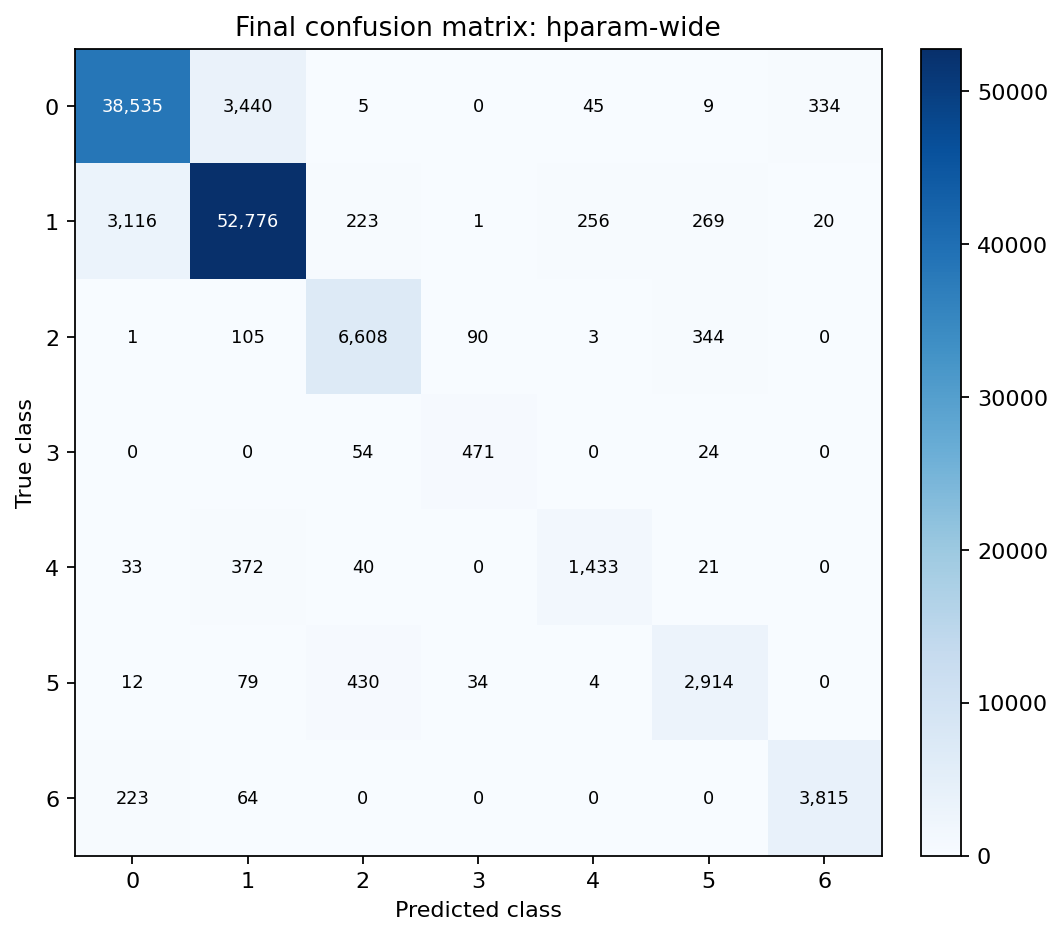

Final evaluation: PASS


In [29]:
# ===== Part 4: lock selection, evaluate baseline and final model =====
import importlib
import json
import os
import shutil
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

import results_table as results_table_module
from train import final_eval, run_experiment

results_table_module = importlib.reload(results_table_module)
load_results = results_table_module.load_results
to_row = results_table_module.to_row
write_xlsx = results_table_module.write_xlsx

all_results = load_results(f"{OUT_DIR}/results")

eligible_results = [
    result
    for result in all_results
    if not result["summary"].get("diverged", False)
    and result["summary"].get("val_macro_f1") is not None
    and (
        result["cfg"].get("group") != "baseline"
        or result["cfg"]["exp_id"] == "base-s42"
    )
]

if not eligible_results:
    raise RuntimeError("Khong co thi nghiem hop le de chon bang validation")

selected_result = max(
    eligible_results,
    key=lambda result: result["summary"]["val_macro_f1"],
)
baseline_result = next(
    result
    for result in all_results
    if result["cfg"]["exp_id"] == "base-s42"
)

selected_exp_id = selected_result["cfg"]["exp_id"]
selection = {
    "criterion": "highest validation macro-F1 among completed experiments",
    "selected_exp_id": selected_exp_id,
    "selected_val_macro_f1": selected_result["summary"]["val_macro_f1"],
    "selected_best_val_loss": selected_result["summary"]["best_val_loss"],
    "selected_best_epoch": selected_result["summary"]["best_epoch"],
    "baseline_exp_id": "base-s42",
    "baseline_val_macro_f1": baseline_result["summary"]["val_macro_f1"],
}

decision_path = f"{OUT_DIR}/selection_decision.json"
final_eval_path = f"{OUT_DIR}/eval_result.json"

if os.path.isfile(final_eval_path):
    if not os.path.isfile(decision_path):
        raise RuntimeError(
            "eval_result.json da ton tai nhung thieu selection_decision.json"
        )

    with open(decision_path, "r", encoding="utf-8") as file:
        previous_selection = json.load(file)

    if previous_selection["selected_exp_id"] != selected_exp_id:
        raise RuntimeError(
            "Eval da duoc chay cho cau hinh khac; khong duoc tune lai bang eval"
        )
else:
    with open(decision_path, "w", encoding="utf-8") as file:
        json.dump(selection, file, indent=2)

print("Selection locked before eval:")
print(json.dumps(selection, indent=2))

baseline_pred_path = f"{OUT_DIR}/predictions_eval_baseline.csv"
baseline_score_path = f"{OUT_DIR}/eval_result_baseline.json"
final_pred_path = f"{OUT_DIR}/predictions_eval.csv"

need_baseline = not os.path.isfile(baseline_score_path)
need_final = not os.path.isfile(final_eval_path)
baseline_checkpoint = None
selected_checkpoint = None

if need_baseline:
    baseline_cfg = {
        **baseline_result["cfg"],
        "exp_id": "eval-retrain-base-s42",
    }
    baseline_checkpoint = run_experiment(baseline_cfg, data)
    final_eval(
        baseline_cfg,
        baseline_checkpoint,
        data,
        baseline_pred_path,
    )

if need_final:
    if selected_exp_id == "base-s42" and baseline_checkpoint is not None:
        selected_checkpoint = baseline_checkpoint
        selected_cfg = baseline_cfg
    else:
        selected_cfg = {
            **selected_result["cfg"],
            "exp_id": f"eval-retrain-{selected_exp_id}",
        }
        selected_checkpoint = run_experiment(selected_cfg, data)

    final_eval(
        selected_cfg,
        selected_checkpoint,
        data,
        final_pred_path,
    )


def run_evaluator(pred_path, score_path):
    if os.path.isfile(score_path):
        print("Loaded existing eval result:", score_path)
        return

    subprocess.run(
        [
            sys.executable,
            "scripts/evaluate.py",
            "--pred",
            pred_path,
            "--out",
            score_path,
        ],
        cwd=REPO_ROOT,
        check=True,
    )


run_evaluator(baseline_pred_path, baseline_score_path)
run_evaluator(final_pred_path, final_eval_path)

with open(baseline_score_path, "r", encoding="utf-8") as file:
    baseline_eval_scores = json.load(file)

with open(final_eval_path, "r", encoding="utf-8") as file:
    final_eval_scores = json.load(file)

print("\nFinal evaluation summary:")
print("configuration        val_macro_f1   eval_accuracy   eval_macro_f1")
print(
    f"base-s42             "
    f"{baseline_result['summary']['val_macro_f1']:<14.4f} "
    f"{baseline_eval_scores['accuracy']:<15.4f} "
    f"{baseline_eval_scores['macro_f1']:.4f}"
)
print(
    f"{selected_exp_id:<20} "
    f"{selected_result['summary']['val_macro_f1']:<14.4f} "
    f"{final_eval_scores['accuracy']:<15.4f} "
    f"{final_eval_scores['macro_f1']:.4f}"
)
print(
    "Eval macro-F1 improvement: "
    f"{final_eval_scores['macro_f1'] - baseline_eval_scores['macro_f1']:+.4f}"
)

print("\nPer-class final evaluation:")
print("class   support   precision   recall   f1")

for item in final_eval_scores["per_class"]:
    print(
        f"{item['cls']:<7d} "
        f"{item['support']:<9d} "
        f"{item['precision']:<11.4f} "
        f"{item['recall']:<8.4f} "
        f"{item['f1']:.4f}"
    )

confusion = np.asarray(final_eval_scores["confusion_matrix"])
hardest = min(final_eval_scores["per_class"], key=lambda item: item["f1"])
hardest_row = confusion[hardest["cls"]].copy()
hardest_row[hardest["cls"]] = -1
most_confused_with = int(hardest_row.argmax())

print(
    f"Hardest class: {hardest['cls']} | F1={hardest['f1']:.4f} | "
    f"most confused with class {most_confused_with}"
)

figure, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(confusion, cmap="Blues")
axis.set_title(f"Final confusion matrix: {selected_exp_id}")
axis.set_xlabel("Predicted class")
axis.set_ylabel("True class")
axis.set_xticks(range(7))
axis.set_yticks(range(7))

for row_index in range(7):
    for column_index in range(7):
        value = confusion[row_index, column_index]
        color = "white" if value > confusion.max() * 0.5 else "black"
        axis.text(
            column_index,
            row_index,
            f"{value:,}",
            ha="center",
            va="center",
            fontsize=8,
            color=color,
        )

figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
figure.tight_layout()
confusion_path = f"{OUT_DIR}/figures/final_confusion_matrix.png"
figure.savefig(confusion_path, dpi=160, bbox_inches="tight")
plt.close(figure)

rows = []

for result in all_results:
    exp_id = result["cfg"]["exp_id"]
    eval_scores = None

    if exp_id == "base-s42":
        eval_scores = baseline_eval_scores

    if exp_id == selected_exp_id:
        eval_scores = final_eval_scores

    rows.append(
        to_row(
            result,
            eval_scores=eval_scores,
            notes=(
                "Selected final configuration using validation only"
                if exp_id == selected_exp_id
                else "See notebook comparison and group figure"
            ),
        )
    )

write_xlsx(
    rows,
    template_path=f"{REPO_ROOT}/templates/experiment_table_template.xlsx",
    out_path=f"{OUT_DIR}/experiments.xlsx",
    summary_notes={
        "final": (
            f"Selected {selected_exp_id} using validation macro-F1 before eval."
        )
    },
)

report_path = f"{OUT_DIR}/REPORT.md"

if not os.path.isfile(report_path):
    shutil.copyfile(
        f"{REPO_ROOT}/templates/REPORT_TEMPLATE.md",
        report_path,
    )
    print("Created report draft:", report_path)

display(Image(filename=confusion_path))
print("Final evaluation: PASS")


### Nhận xét eval và phân tích lỗi

Cấu hình được khóa trước khi xem eval là `hparam-wide`, chọn bằng validation macro-F1 `0,8721` tại checkpoint có validation loss thấp nhất ở epoch 18. Trên eval, baseline `base-s42` đạt accuracy `0,9053`, macro-F1 `0,8596`; `hparam-wide` đạt accuracy `0,9169`, macro-F1 `0,8734`. Mức tăng eval macro-F1 là `0,0138`: có cải thiện thực đo nhưng vẫn nhỏ hơn ngưỡng nhiễu validation `2σ = 0,0175`, vì vậy chưa nên khẳng định kiến trúc wide luôn tốt hơn trên seed khác. Validation và eval của cấu hình cuối chỉ lệch `0,0013`, cho thấy hai tập có hành vi khá nhất quán.

Lớp khó nhất là lớp 4 với support `1.899`, precision `0,8231`, recall `0,7546` và F1 `0,7874`; lỗi phổ biến nhất của lớp này là bị dự đoán thành lớp 1. Lớp 4 chỉ chiếm khoảng `1,63%` dữ liệu eval và có ít ví dụ hơn nhiều so với lớp 1 (`56.661` mẫu), nên mất cân bằng lớp và vùng đặc trưng chồng lấn có thể khiến biên quyết định thiên về lớp 1. Một hướng cải thiện hợp lý là thử class-weighted cross-entropy hoặc lấy mẫu cân bằng, nhưng chưa được dùng để chỉnh mô hình sau khi đã xem eval.
